In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

In [4]:
playoffs = pd.read_csv("C:/Users/kurtg/Downloads/nhlplayoffs.csv")
playoffs.head(17)
playoffs.loc[704, 'year'] = 1977  #had the incorrect year, had to change it
playoffs = playoffs.loc[playoffs['year'] >= 1927]  #I chose to start at 1926 since that was the first year where solely NHL teams would compete for the Stanley Cup
                                                   #I also chose to leave out 1926 since only 3 teams competed and that just made me do more work for little to no new information

In [119]:
#This section is to add in a column that describes which round in the playoffs a team loses in

playoffs['num_teams'] = playoffs.groupby('year')['team'].transform('count')

playoffs['round'] = np.select(
    [
        # Winners / finalists
        playoffs['rank'] == 1,
        playoffs['rank'] == 2,

        # --- 12 TEAM SPECIAL CASE ---
        (playoffs['num_teams'] == 12) & (playoffs['rank'] >= 9),   # bottom 4
        (playoffs['num_teams'] == 12) & (playoffs['rank'].between(5, 8)),
        (playoffs['num_teams'] == 12) & (playoffs['rank'].between(3, 4)),

        # 6 team special case
        (playoffs['num_teams'] == 6) & (playoffs['rank'] >= 5),
        (playoffs['num_teams'] == 6) & (playoffs['rank'].between(3, 4)),
        
        # --- STANDARD FORMATS ---
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'] // 4),
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'] // 2),
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'])
    ],
    [
        'Won Stanley Cup',
        'Lost Stanley Cup Finals',

        # 12-team labels
        'Lost Round of 12',
        'Lost Quarterfinals',
        'Lost Semi-Finals',

        #6-team labels
        'Lost Quarterfinals',
        'Lost Semi-Finals',
        
        # standard labels
        'Lost Semi-Finals',
        'Lost Quarterfinals',
        'Lost Round of ' + playoffs['num_teams'].astype(str)
    ],
    default=np.nan
)

playoffs.loc[playoffs['num_teams'] == 8, 'round'] = playoffs['round'].replace(
    'Lost Round of 8', 'Lost Quarterfinals'
)

playoffs.loc[playoffs['num_teams'] == 4, 'round'] = playoffs['round'].replace(
    'Lost Round of 4', 'Lost Semi-Finals'
)

playoffs['round'] = pd.Categorical(playoffs['round'])
playoffs.head()

,rank,team,year,games,wins,losses,ties,shootout_wins,shootout_losses,win_loss_percentage,goals_scored,goals_against,goal_differential,num_teams,round,ratio_rank,round_code
0,1,Colorado Avalanche,2022,20,16,4,0,5,1,0.800,85,55,30,16,Won Stanley Cup,0.9375,6
1,2,Tampa Bay Lightning,2022,23,14,9,0,1,2,0.609,67,61,6,16,Lost Stanley Cup Finals,0.8750,5
2,3,New York Rangers,2022,20,10,10,0,1,2,0.500,62,58,4,16,Lost Semi-Finals,0.8125,4
3,4,Edmonton Oilers,2022,16,8,8,0,1,2,0.500,65,59,6,16,Lost Semi-Finals,0.7500,4
4,5,Carolina Hurricanes,2022,14,7,7,0,1,0,0.500,37,40,-3,16,Lost Quarterfinals,0.6875,0


# How does playoff record determine outcomes?

C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\4094831675.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter['round'] = pd.Categorical(filter['round'], categories=order, ordered=True)
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\4094831675.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  histograms = filter.hist(column='win_loss_percentage',by='round',


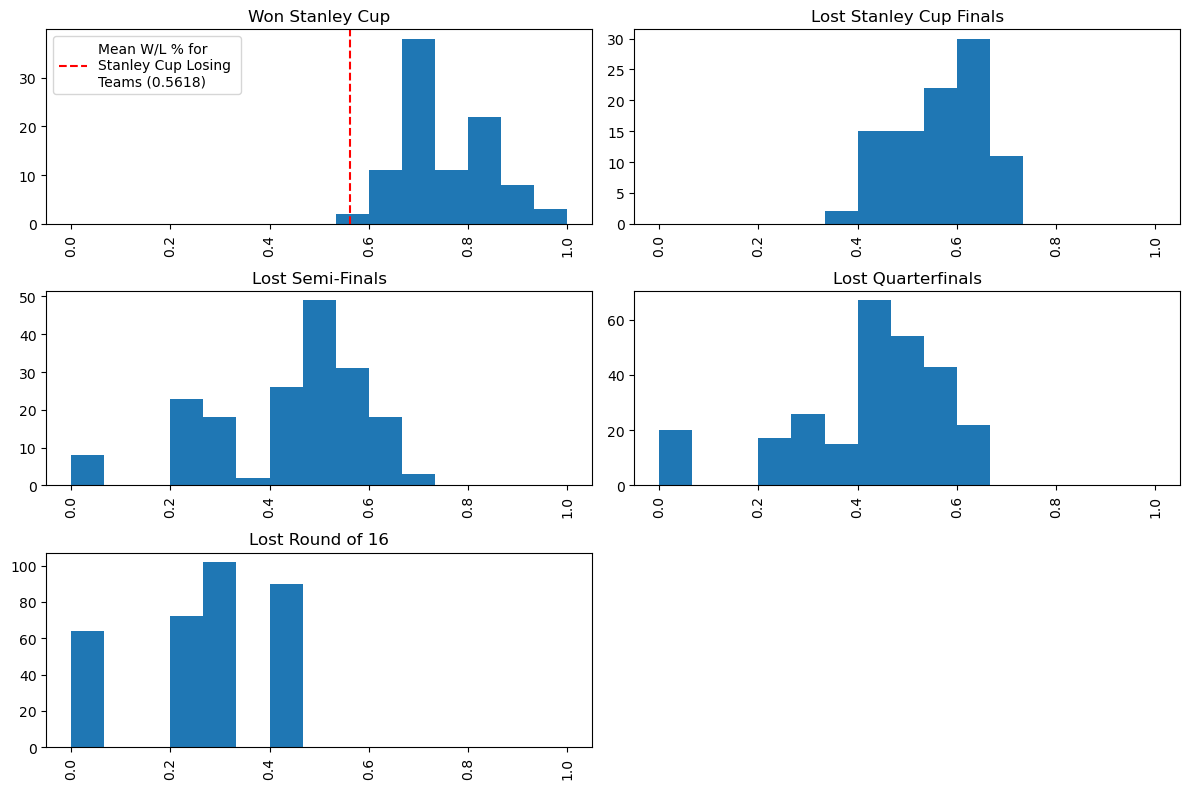

In [37]:
order = ['Won Stanley Cup',
        'Lost Stanley Cup Finals',
        'Lost Semi-Finals',
        'Lost Quarterfinals',
        'Lost Round of 16']

filter = playoffs[(playoffs['round'] != 'Lost Round of 3') & (playoffs['round'] != 'Lost Round of 24') & (playoffs['round'] != 'Lost Round of 12')]
filter['round'] = pd.Categorical(filter['round'], categories=order, ordered=True)
mean_wl_losing = filter.loc[filter['round'] == 'Lost Stanley Cup Finals', 'win_loss_percentage'].mean()

histograms = filter.hist(column='win_loss_percentage',by='round',
                           bins=15, figsize=(12,8), range=(0,1))

ax = histograms.flatten()[0]
ax.axvline(mean_wl_losing, linestyle='--', color='red', label=f'Mean W/L % for \nStanley Cup Losing \nTeams ({mean_wl_losing})')
ax.legend()

plt.tight_layout()
plt.show()

In [131]:
index = playoffs.loc[playoffs['round'] == 'Won Stanley Cup','win_loss_percentage'].idxmin()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Worst Playoff record is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

index = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] == 16), 'win_loss_percentage'].idxmin()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Worst Playoff record in a 16 team playoff is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

print()

index = playoffs.loc[playoffs['round'] == 'Won Stanley Cup','win_loss_percentage'].idxmax()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Best Playoff record is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

index = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] == 16), 'win_loss_percentage'].idxmax()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Best Playoff record in a 16 team playoff is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

print()

index = playoffs.loc[playoffs['round'] == 'Lost Stanley Cup Finals','win_loss_percentage'].idxmax()
losing_team_best = playoffs.loc[index,'team']
losing_best_rec = playoffs.loc[index,'win_loss_percentage']
losing_year_best_rec = playoffs.loc[index,'year']
print(f'The NHL Team to lose the Stanley Cup with the Best Playoff record is {losing_team_best} in {losing_year_best_rec}, with a win-loss percentage of {losing_best_rec}')

The NHL Team to win the Stanley Cup with the Worst Playoff record is Toronto Maple Leafs in 1964, with a win-loss percentage of 0.571
The NHL Team to win the Stanley Cup with the Worst Playoff record in a 16 team playoff is St. Louis Blues in 2019, with a win-loss percentage of 0.615

The NHL Team to win the Stanley Cup with the Best Playoff record is Montreal Canadiens in 1960, with a win-loss percentage of 1.0
The NHL Team to win the Stanley Cup with the Best Playoff record in a 16 team playoff is Edmonton Oilers in 1988, with a win-loss percentage of 0.868

The NHL Team to win the Stanley Cup with the Worst Playoff record is Mighty Ducks of Anaheim in 2003, with a win-loss percentage of 0.714


Text(0, 0.5, 'Playoff Win Loss Percentage')

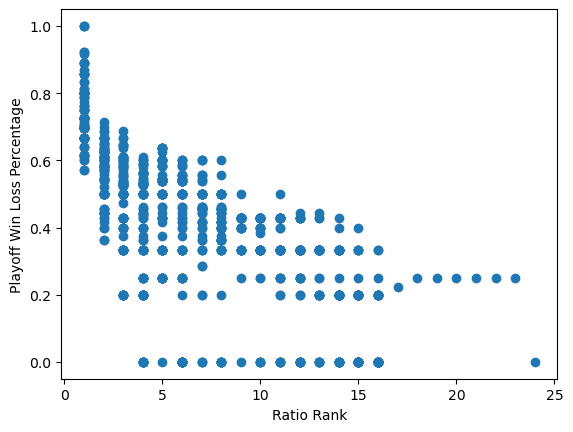

In [266]:
playoffs['ratio_rank'] = 1 - (playoffs['rank']/playoffs['num_teams'])

plt.plot(playoffs['rank'],playoffs['win_loss_percentage'],'o')
plt.xlabel('Ratio Rank')
plt.ylabel('Playoff Win Loss Percentage')

# How does the number of playoff games determine the outcome?

In [87]:
avg_won_stanley = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] >= 16), 'games'].mean()
avg_lost_stanley = playoffs.loc[(playoffs['round'] == 'Lost Stanley Cup Finals') & (playoffs['num_teams'] >= 16), 'games'].mean()

print(f'Average number of Games for teams that Won the Stanley Cup Finals: {round(avg_won_stanley,2)}')
print(f'Average number of Games for teams that Lost the Stanley Cup Finals: {round(avg_lost_stanley,2)}')

Average number of Games for teams that Won the Stanley Cup Finals: 22.1
Average number of Games for teams that Lost the Stanley Cup Finals: 22.05


C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\3019480074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter2['round'] = filter2['round'].cat.remove_unused_categories()
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\3019480074.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filter2.hist(column='games',by='round',


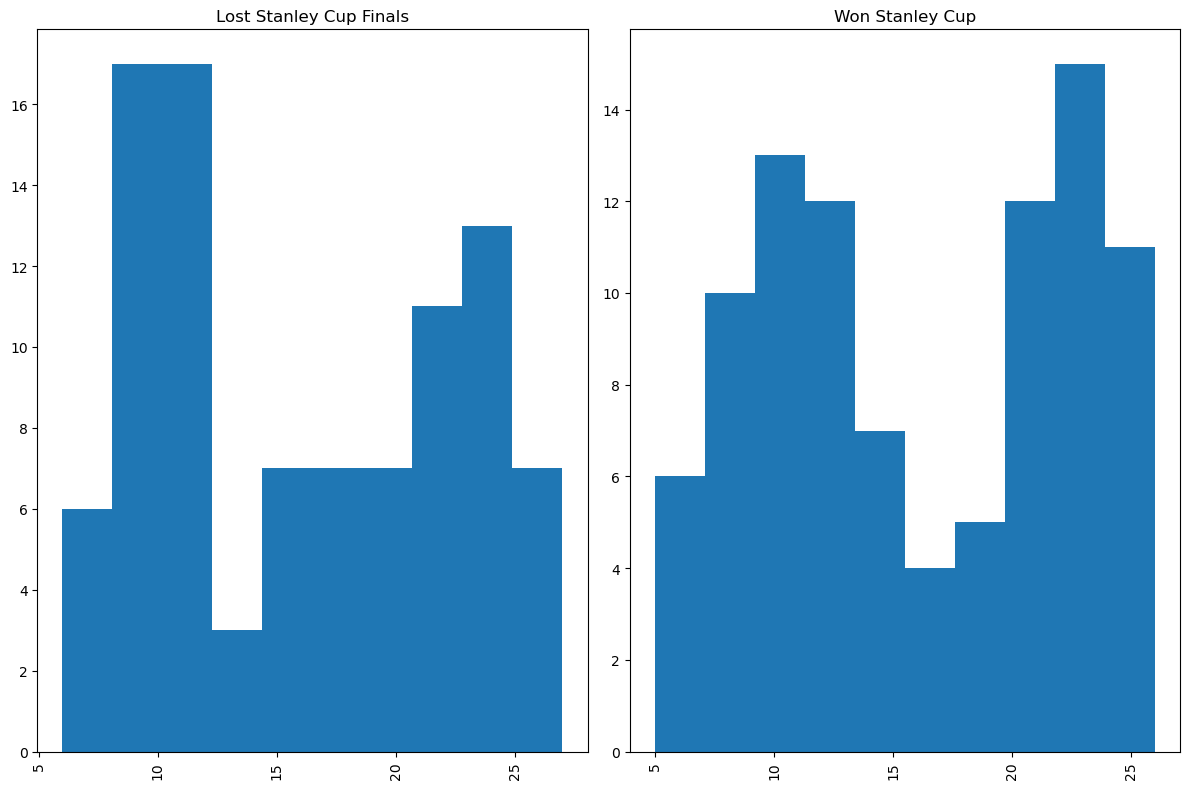

In [109]:
filter2 = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') | (playoffs['round'] == 'Lost Stanley Cup Finals')]
filter2['round'] = filter2['round'].cat.remove_unused_categories()

filter2.hist(column='games',by='round',
            bins=10, figsize=(12,8))
plt.tight_layout()
plt.show()

A little hard to tell, but the histograms seem to mirror each other a little bit. Both have big spikes with a big dip in the middle almost forming a 'parabola' shape. However, the highest points are on completely different parts. For Stanley Cup losers, their peak in the histogram comes early around 10 games while Stanley Cup winners see their largest peak around the 22 game mark. This indicates that while the number of playoff games played doesn't have too much as an indicator for who will win the Stanley Cup, it can be a better to have played more games in the playoffs.

# How do goals for and goals against determine outcomes?

## Goals For

<Axes: title={'center': 'goals_scored'}, xlabel='round'>

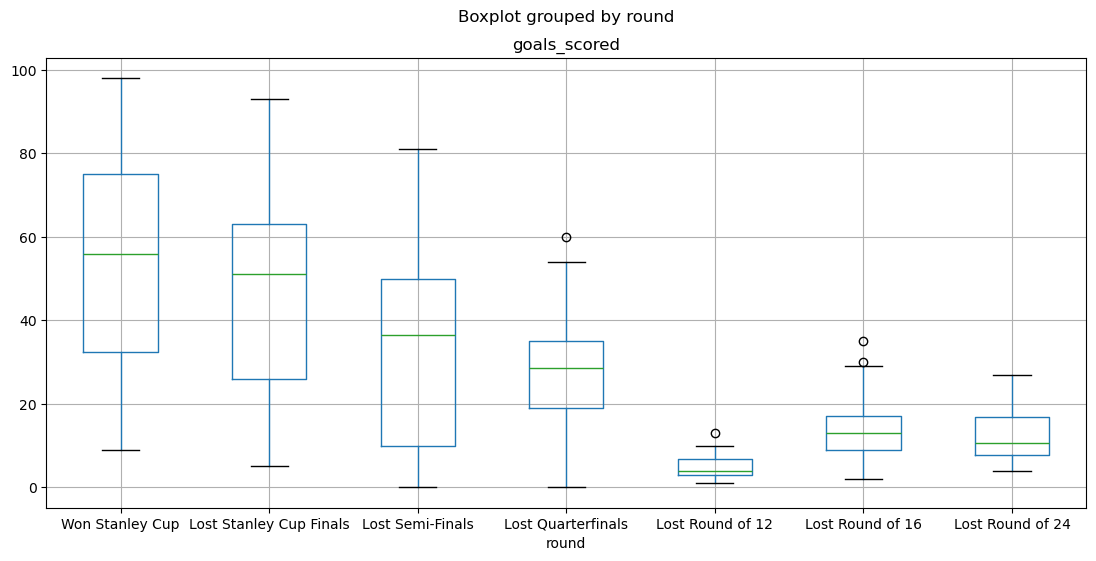

In [179]:
order2 = ['Won Stanley Cup',
        'Lost Stanley Cup Finals',
        'Lost Semi-Finals',
        'Lost Quarterfinals',
          'Lost Round of 12',
        'Lost Round of 16',
         'Lost Round of 24']
playoffs['round'] = playoffs['round'].cat.reorder_categories(order2, ordered=True)

playoffs.boxplot(column='goals_scored',by='round',figsize=(13,6))

C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\1460239762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter3['round'] = filter3['round'].cat.remove_unused_categories()
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\1460239762.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter3['round'] = pd.Categorical(filter3['round'], categories=order, ordered=True)


<Axes: title={'center': 'goals_scored'}, xlabel='round'>

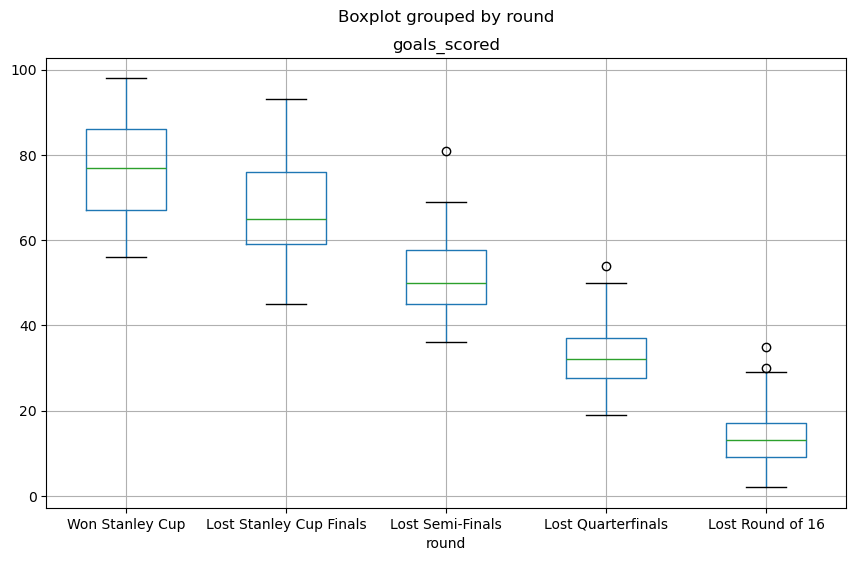

In [171]:
filter3 = playoffs.loc[playoffs['num_teams'] == 16]
filter3['round'] = filter3['round'].cat.remove_unused_categories()
filter3['round'] = pd.Categorical(filter3['round'], categories=order, ordered=True)
filter3.boxplot(column='goals_scored',by='round',figsize=(10,6))

<Axes: title={'center': 'goals_per_game'}, xlabel='round'>

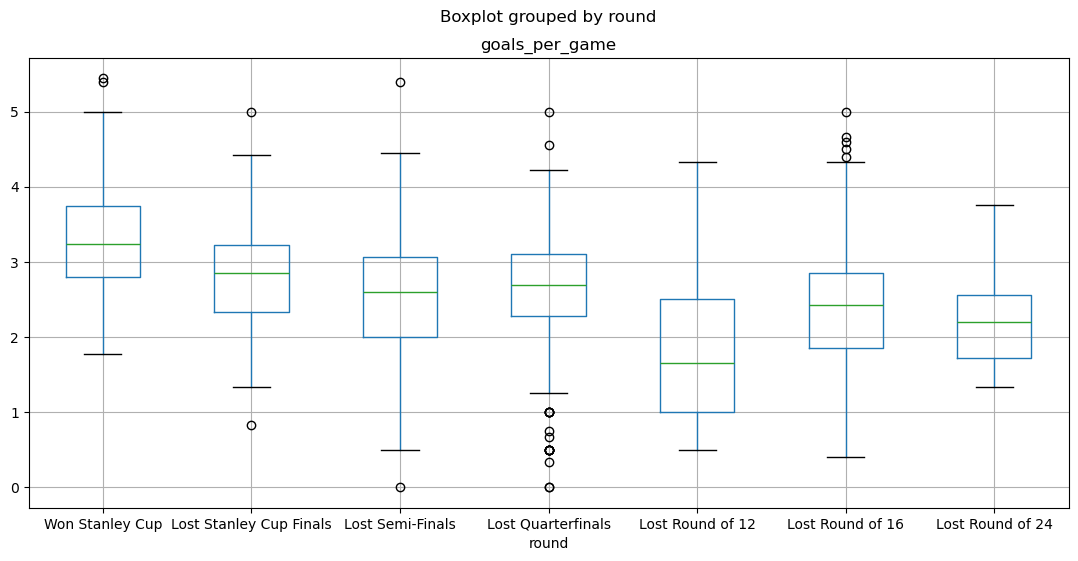

In [185]:
playoffs['goals_per_game'] = playoffs['goals_scored']/playoffs['games']
playoffs.boxplot(column='goals_per_game',by='round',figsize=(13,6))

C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\2858406421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter3['round'] = filter3['round'].cat.remove_unused_categories()
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\2858406421.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter3['round'] = pd.Categorical(filter3['round'], categories=order, ordered=True)


<Axes: title={'center': 'goals_per_game'}, xlabel='round'>

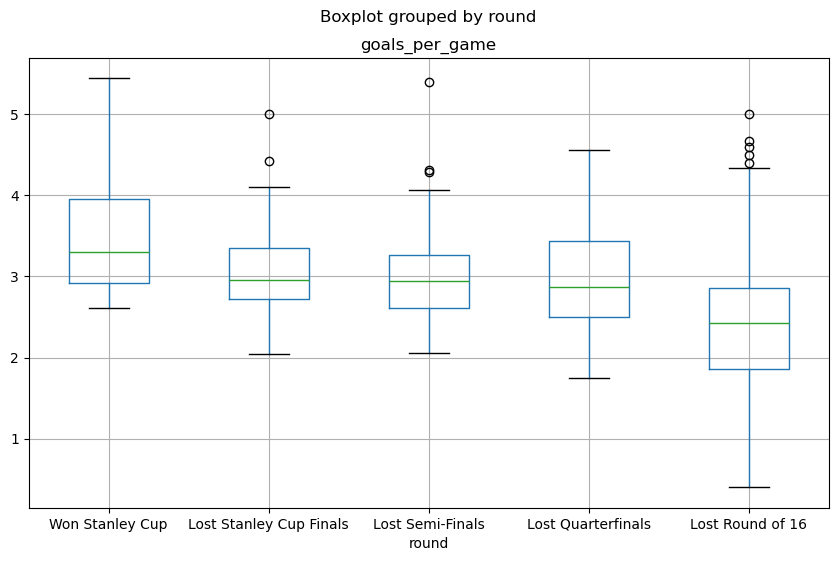

In [189]:
filter3 = playoffs.loc[playoffs['num_teams'] == 16]
filter3['round'] = filter3['round'].cat.remove_unused_categories()
filter3['round'] = pd.Categorical(filter3['round'], categories=order, ordered=True)
filter3.boxplot(column='goals_per_game',by='round',figsize=(10,6))

## Goals Against

C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\987635230.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter4['round'] = filter4['round'].cat.remove_unused_categories()
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\987635230.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter4['round'] = pd.Categorical(filter4['round'], categories=order, ordered=True)


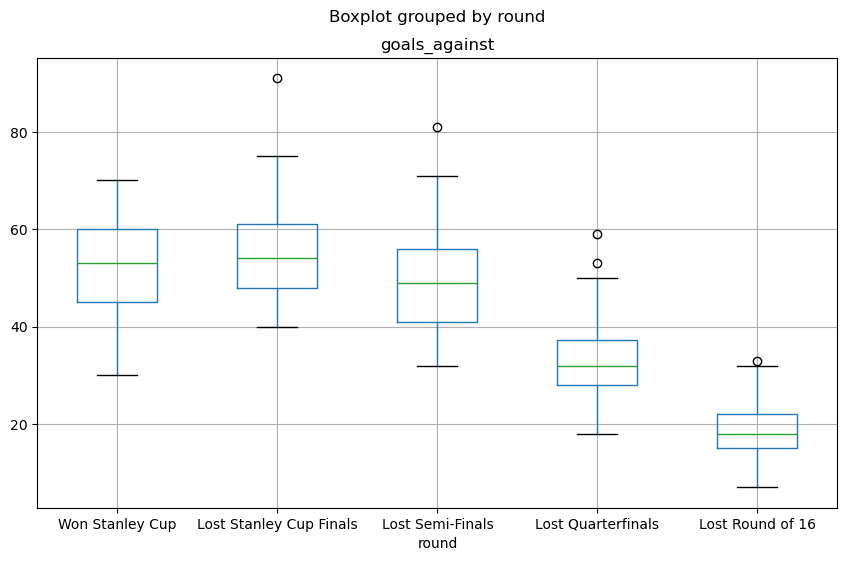

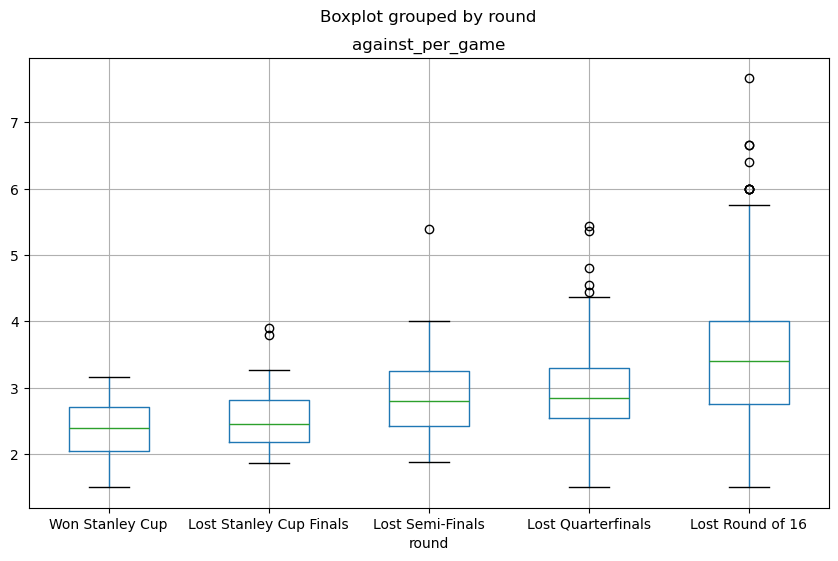

In [232]:
playoffs['against_per_game'] = playoffs['goals_against']/playoffs['games']
filter4 = playoffs.loc[playoffs['num_teams'] == 16]
filter4['round'] = filter4['round'].cat.remove_unused_categories()
filter4['round'] = pd.Categorical(filter4['round'], categories=order, ordered=True)
filter4.boxplot(column='goals_against',by='round',figsize=(10,6))

filter4.boxplot(column='against_per_game',by='round',figsize=(10,6))
plt.show()

C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\3799195555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter5['round'] = filter5['round'].cat.remove_unused_categories()
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\3799195555.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter5['round'] = pd.Categorical(filter5['round'], categories=order, ordered=True)
C:\Users\kurtg\AppData\Local\Temp\ipykernel_23212\3799195555.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

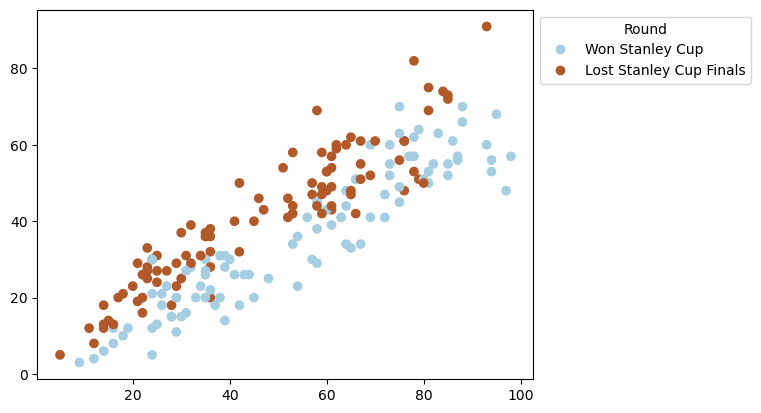

In [262]:
filter5 = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') | (playoffs['round'] == 'Lost Stanley Cup Finals')]
filter5['round'] = filter5['round'].cat.remove_unused_categories()
filter5['round'] = pd.Categorical(filter5['round'], categories=order, ordered=True)
filter5['round_code'] = filter5['round'].cat.codes

scatter = plt.scatter(filter5['goals_scored'],filter5['goals_against'],
                    c=filter5['round_code'],
                    cmap='Paired')

handles, _ = scatter.legend_elements()
labels = filter5['round'].cat.categories

plt.legend(handles, labels, title='Round',loc='upper left',
           bbox_to_anchor=(1, 1))

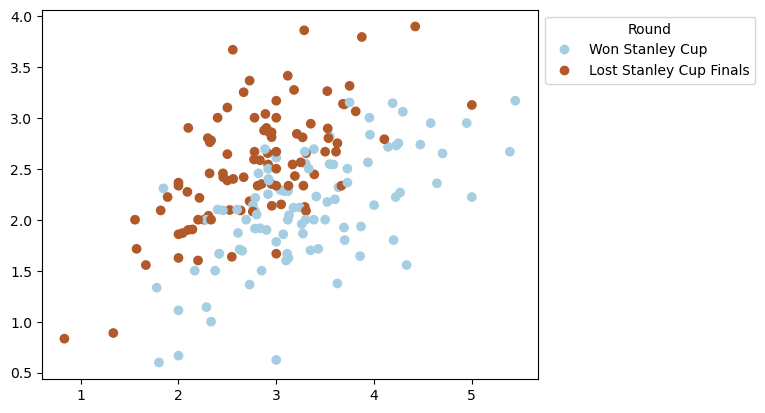

In [264]:
scatter = plt.scatter(filter5['goals_per_game'],filter5['against_per_game'],
                    c=filter5['round_code'],
                    cmap='Paired')

handles, _ = scatter.legend_elements()
labels = filter5['round'].cat.categories

plt.legend(handles, labels, title='Round',loc='upper left',
           bbox_to_anchor=(1, 1))

# New Data Set

In [286]:
season = pd.read_csv("C:/Users/kurtg/Downloads/Untitled spreadsheet - Sheet1.csv")
season['Team'] = season['Team'].str.replace('*', '', regex=False).str.strip()
season['pts_percent'] = round(season['PTS']/(season['GP'] *2),3)
season['win_percent'] = round(season['W']/season['GP'],3)
season.columns = season.columns.str.lower()
season = season.rename(columns={'season':'year'})
season.head()

,year,lg,team,gp,w,l,t,ol,pts,pts_percent,win_percent
0,2022,NHL,Anaheim Ducks,82,31,37,NaN,14.0,76,0.463,0.378
1,2021,NHL,Anaheim Ducks,56,17,30,NaN,9.0,43,0.384,0.304
2,2020,NHL,Anaheim Ducks,71,29,33,NaN,9.0,67,0.472,0.408
3,2019,NHL,Anaheim Ducks,82,35,37,NaN,10.0,80,0.488,0.427
4,2018,NHL,Anaheim Ducks,82,44,25,NaN,13.0,101,0.616,0.537


In [288]:
playoff_season = pd.merge(playoffs, season, on=['year','team'])
playoff_season.head()

,rank,team,year,games,wins,losses,ties,shootout_wins,shootout_losses,win_loss_percentage,...,against_per_game,lg,gp,w,l,t,ol,pts,pts_percent,win_percent
0,1,Colorado Avalanche,2022,20,16,4,0,5,1,0.800,...,2.750000,NHL,82,56,19,NaN,7.0,119,0.726,0.683
1,2,Tampa Bay Lightning,2022,23,14,9,0,1,2,0.609,...,2.652174,NHL,82,51,23,NaN,8.0,110,0.671,0.622
2,3,New York Rangers,2022,20,10,10,0,1,2,0.500,...,2.900000,NHL,82,52,24,NaN,6.0,110,0.671,0.634
3,4,Edmonton Oilers,2022,16,8,8,0,1,2,0.500,...,3.687500,NHL,82,49,27,NaN,6.0,104,0.634,0.598
4,6,St. Louis Blues,2022,12,6,6,0,1,1,0.500,...,3.166667,NHL,82,49,22,NaN,11.0,109,0.665,0.598


## How does regular season record determine outcome?

In [ ]:
#Regular Season Win Percentage Vs Playoff Record
#Points Percentage Vs Playoff Record

## Is there a significant change between regular season and playoff records?

In [ ]:
#Percent Change

## How do overtime losses/shootout losses determine outcomes?
### Does more OT losses decrease your odds in any substantial way

In [ ]:
#Overtime Losses Histogram w/ Different Rounds??
#Overtime Losses Boxplot by Round?
#Compare Mean Overtime Losses between Rounds??
#Compare Ratios of Overtime Losses/Game in Regular Season vs OTL/G in Playoffs (shootout_loss)
        #Use those Ratios for Histgram/Boxplot like above